In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import re
import string

In [5]:
fake_df = pd.read_csv("data/raw/Fake.csv")
true_df = pd.read_csv("data/raw/True.csv")

In [6]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [7]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


## EDA

### Dataset Overview

The dataset consists of two subsets: fake news articles and real news articles.

- **Fake news:** 23,481 articles
- **Real news:** 21,417 articles
- **Total:** 44,898 articles

Each article contains four features: `title`, `text`, `subject`, and `date`.

The two classes are relatively balanced, which limits the need for class-balancing techniques at this stage.

In [20]:
print("Fake news shape:", fake_df.shape)
print("True news shape:", true_df.shape)

Fake news shape: (23481, 4)
True news shape: (21417, 4)


In [21]:
fake_df.info()
true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


### Missing Values

No missing values were identified in either dataset across the four available columns (`title`, `text`, `subject`, and `date`).

However, empty strings may still be present, as they are not detected by `isna()`. These will be investigated separately during data quality analysis.

In [22]:
fake_df.isna().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [23]:
true_df.isna().sum()

title      0
text       0
subject    0
date       0
dtype: int64

### Duplicate Records

Duplicate records were identified in both datasets:

- **Fake news:** 3 duplicate records
- **Real news:** 206 duplicate records

Duplicate articles may introduce unnecessary redundancy and potentially bias model evaluation if identical articles are distributed across the training and test sets.

Therefore, exact duplicates will be removed before further analysis and modeling.

In [24]:
print("Fake duplicates:", fake_df.duplicated().sum())
print("True duplicates:", true_df.duplicated().sum())

Fake duplicates: 3
True duplicates: 206


In [29]:
fake_df = fake_df.drop_duplicates().reset_index(drop=True)
true_df = true_df.drop_duplicates().reset_index(drop=True)

In [30]:
print("Fake duplicates:", fake_df.duplicated().sum())
print("True duplicates:", true_df.duplicated().sum())

Fake duplicates: 0
True duplicates: 0


### Subject Distribution and Potential Target Leakage

The distribution of the `subject` variable differs completely between the two classes.

Real articles belong exclusively to the `politicsNews` and `worldnews` categories, while fake articles use different categories : `News`, `politics`, `left-news`, `Government News`, `US_News`, and `Middle-east`.

As a result, `subject` is strongly associated with the target label and could allow a model to distinguish fake from real articles without analyzing their actual content.

For this reason, `subject` will not be used as a predictive feature.

In [32]:
fake_df["subject"].value_counts()

subject
News               9050
politics           6838
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

In [33]:
true_df["subject"].value_counts()

subject
politicsNews    11220
worldnews        9991
Name: count, dtype: int64

### Source Artifact: Reuters Mentions

A major source-related artifact was identified in the article text.

- Approximately **1.37% of fake articles** contain the term `Reuters`.
- Approximately **99.82% of real articles** contain the term `Reuters`.

This is consistent with the dataset collection methodology, as the real articles were collected from Reuters, whereas fake articles originated from multiple unreliable news sources.

This creates a significant risk of source leakage: a text classification model could achieve very high performance simply by learning Reuters-specific markers rather than linguistic patterns associated with misinformation.

Reuters-related source markers will therefore require special attention during preprocessing and model evaluation.

In [34]:
fake_df["text"].str.contains("Reuters", case=False, na=False).mean()

np.float64(0.013714967203339297)

In [35]:
true_df["text"].str.contains("Reuters", case=False, na=False).mean()

np.float64(0.9981613313846589)

In [36]:
fake_df["label"] = 0
true_df["label"] = 1

In [38]:
fake_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [39]:
true_df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


### Dataset Merging


In [40]:
df = pd.concat([fake_df, true_df], ignore_index=True)

In [41]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


### Missing and Empty Values

No standard missing values (`NaN`) were identified in the dataset. However, checking for empty strings revealed 631 articles with an empty `text` field.

Their class distribution is highly imbalanced:

- **Fake news:** 630 articles
- **Real news:** 1 article

Therefore, approximately 99.8% of articles with an empty body belong to the fake-news class.

Although these observations still contain a title, the near-perfect association between an empty article body and the target label represents another potential dataset artifact. Moreover, articles without textual content cannot be meaningfully used in a model intended to classify article bodies.

These observations will therefore be removed before text-based modeling.

In [ ]:
df["label"].value_counts()

label
0    23478
1    21211
Name: count, dtype: int64

In [43]:
(df["title"].str.strip() == "").sum()

np.int64(0)

In [44]:
(df["text"].str.strip() == "").sum()

np.int64(631)

In [47]:
(df["subject"].str.strip() == "").sum()

np.int64(0)

In [48]:
df[df["text"].str.strip() == ""]["label"].value_counts()

label
0    630
1      1
Name: count, dtype: int64

In [49]:
df[df["text"].str.strip() == ""][["title", "subject", "label"]].head(10)

,title,subject,label
10922,TAKE OUR POLL: Who Do You Think President Trum...,politics,0
11040,Joe Scarborough BERATES Mika Brzezinski Over “...,politics,0
11189,WATCH TUCKER CARLSON Scorch Sanctuary City May...,politics,0
11224,MAYOR OF SANCTUARY CITY: Trump Trying To Make ...,politics,0
11235,SHOCKER: Public School Turns Computer Lab Into...,politics,0
11240,BOOM! SEAN SPICER: “Trump Sold Hotels In Russi...,politics,0
11246,MICHAEL FLYNN’S LAWYER Releases Statement Scor...,politics,0
11248,ROB SCHNEIDER Nails The Russia Conspiracy Theo...,politics,0
11266,TREY GOWDY ON SPYING ON AMERICAN CITIZENS…Like...,politics,0
11267,SEAN SPICER CALLS OUT Race Baiting Journalist:...,politics,0


In [50]:
df = df[df["text"].str.strip() != ""].reset_index(drop=True)

In [51]:
(df["text"].str.strip() == "").sum()

np.int64(0)

In [52]:
df.shape

(44058, 5)

### Article Length Analysis

Article length was analyzed using both character count and word count.

The median article lengths are relatively similar across classes, with approximately **369 words for fake articles** and **359 words for real articles**.

However, fake articles exhibit greater variability in length, with a higher standard deviation and more extreme maximum values. This suggests that article length alone is unlikely to provide a clear separation between fake and real news, although differences in the distributions may still exist.

Very short articles are investigated separately to identify potential data quality issues or outliers before modeling.

In [53]:
df["text_length"] = df["text"].str.len()

In [54]:
df.groupby("label")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,22848.0,2617.773241,2531.650609,5.0,1517.75,2200.0,3059.00,51794.0
1,21210.0,2378.154408,1684.428140,152.0,904.00,2216.0,3226.75,29781.0


In [55]:
df["word_count"] = df["text"].str.split().str.len()

In [56]:
df.groupby("label")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,22848.0,434.893951,407.823671,1.0,254.0,369.0,511.0,8135.0
1,21210.0,384.775625,273.898818,22.0,147.0,359.0,523.0,5172.0


#### Very Short Articles

A total of **538 articles contain 20 words or fewer**, all of which belong to the fake-news class.

Manual inspection shows that these observations are heterogeneous. Some consist only of URLs or short source-related markers, while others contain genuine but very short textual content.

Because a simple word-count threshold would exclusively remove observations from the fake-news class and could artificially alter the class-specific text distribution, no minimum-length filtering is applied at this stage.

The strong association between very short content and the fake-news class is instead retained as a potential dataset/source artifact to consider during model evaluation.

In [57]:
df.nsmallest(10, "word_count")[
    ["text", "word_count", "label"]
]

,text,word_count,label
9358,https://100percentfedup.com/served-roy-moore-v...,1,0
11114,Enjoy:,1,0
11242,https://www.youtube.com/watch?v=cJZFepSvxzM,1,0
11272,https://www.youtube.com/watch?v=-7Tn4gi_Os8,1,0
11274,https://www.youtube.com/watch?time_continue=2&...,1,0
11290,https://www.youtube.com/watch?v=SH0pRtK9sAE,1,0
11291,https://www.youtube.com/watch?v=DRLVvYzG46w,1,0
11300,https://www.youtube.com/watch?v=Ws5ojb0PCCo,1,0
11346,https://www.youtube.com/watch?v=P-TBfkqk7gU,1,0
11380,https://www.youtube.com/watch?v=yRXmFmgoPTk,1,0


In [58]:
df[df["word_count"] <= 20]["label"].value_counts()

label
0    538
Name: count, dtype: int64

In [59]:
df[df["word_count"] <= 20]["word_count"].value_counts().sort_index()

word_count
1     98
2     18
3     19
4      8
5     11
6     17
7     26
8     23
9     16
10    13
11    23
12    18
13    24
14    25
15    21
16    34
17    33
18    33
19    40
20    38
Name: count, dtype: int64

In [60]:
df[df["word_count"] <= 20][
    ["text", "word_count", "label"]
].head(30)

,text,word_count,label
9358,https://100percentfedup.com/served-roy-moore-v...,1,0
11114,Enjoy:,1,0
11228,Watch my #OpeningStatment pic.twitter.com/Qp...,10,0
11242,https://www.youtube.com/watch?v=cJZFepSvxzM,1,0
11267,We have to agree that this one is actually pre...,17,0
11272,https://www.youtube.com/watch?v=-7Tn4gi_Os8,1,0
11274,https://www.youtube.com/watch?time_continue=2&...,1,0
11290,https://www.youtube.com/watch?v=SH0pRtK9sAE,1,0
11291,https://www.youtube.com/watch?v=DRLVvYzG46w,1,0
11296,Read more:WT,2,0


### Distribution of Article Length

The distribution of article length is compared between fake and real news using the number of words per article.

Because a small number of extremely long articles would compress the main distribution, the visualization is restricted to observations below the 99th percentile. These observations are excluded from the visualization only and remain in the dataset.

Density normalization is used to compare the shape of the two class distributions despite their slightly different sample sizes.

In [61]:
q99 = df["word_count"].quantile(0.99)
q99

np.float64(1523.8600000000006)

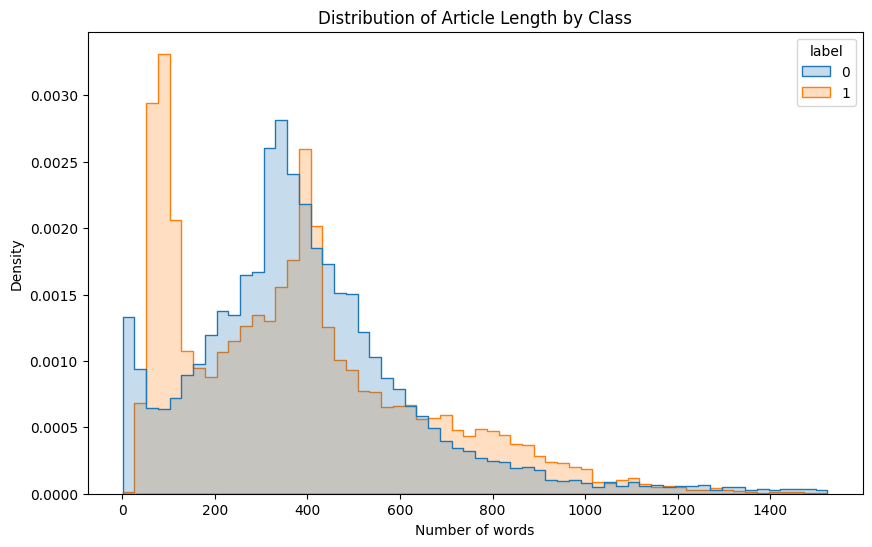

In [62]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df[df["word_count"] <= q99],
    x="word_count",
    hue="label",
    bins=60,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Distribution of Article Length by Class")
plt.xlabel("Number of words")
plt.ylabel("Density")
plt.show()

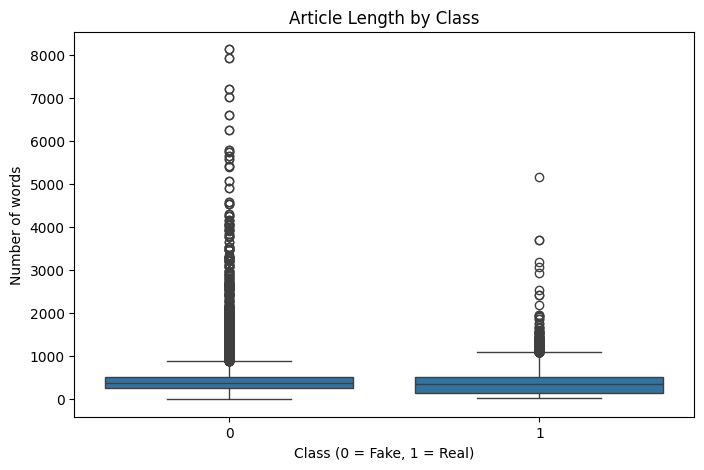

In [63]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="word_count"
)

plt.title("Article Length by Class")
plt.xlabel("Class (0 = Fake, 1 = Real)")
plt.ylabel("Number of words")
plt.show()

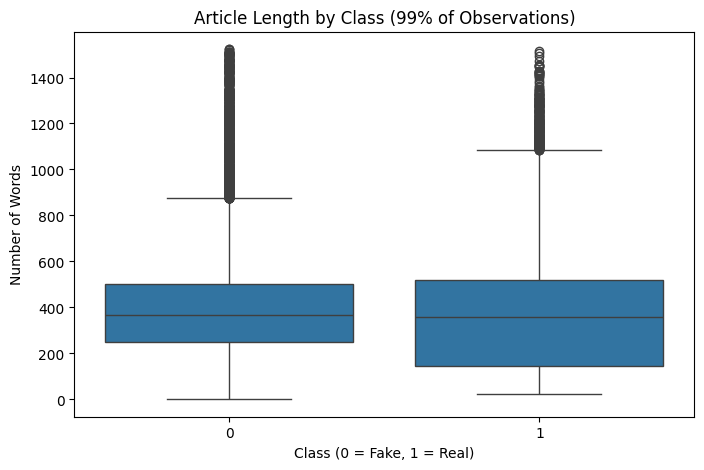

In [64]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df[df["word_count"] <= q99],
    x="label",
    y="word_count"
)

plt.title("Article Length by Class (99% of Observations)")
plt.xlabel("Class (0 = Fake, 1 = Real)")
plt.ylabel("Number of Words")
plt.show()

#### Interpretation

The article-length distributions of fake and real news overlap substantially. Their median lengths are particularly similar, at approximately **369 words for fake articles** and **359 words for real articles**, suggesting that article length alone does not provide a clear separation between the two classes.

However, differences in the shape and dispersion of the distributions can be observed. Real articles show a noticeable concentration among shorter articles, while fake articles exhibit greater variability and a larger number of extremely long observations.

The 99th percentile of article length is **1,523 words**, meaning that 99% of articles contain no more than 1,523 words. Articles above this threshold were excluded from the histogram visualization only to improve readability; they remain part of the dataset.

Overall, article length may contain some class-related information, but the substantial overlap indicates that it is unlikely to be sufficient as a standalone predictor.

### Textual Content Analysis

To better understand the linguistic characteristics of the dataset, word-frequency patterns are examined separately for fake and real articles.

The analysis is initially performed on minimally transformed text in order to identify dominant vocabulary and potential source-related artifacts. Common stopwords are subsequently excluded from the exploratory frequency analysis to reveal more informative terms.

These transformations are performed for exploratory purposes only and do not modify the original article text.

In [66]:
from collections import Counter

In [67]:
fake_text = " ".join(df.loc[df["label"] == 0, "text"])
true_text = " ".join(df.loc[df["label"] == 1, "text"])

In [68]:
fake_words = re.findall(r"\b[a-zA-Z]+\b", fake_text.lower())
true_words = re.findall(r"\b[a-zA-Z]+\b", true_text.lower())

In [69]:
Counter(fake_words).most_common(20)

[('the', 543522),
 ('to', 290799),
 ('of', 236621),
 ('and', 226965),
 ('a', 214769),
 ('in', 171151),
 ('that', 151652),
 ('s', 141154),
 ('is', 111228),
 ('for', 93477),
 ('on', 83590),
 ('it', 83376),
 ('trump', 79300),
 ('he', 78996),
 ('was', 67853),
 ('with', 63410),
 ('his', 58351),
 ('this', 58214),
 ('as', 57760),
 ('be', 49257)]

In [70]:
Counter(true_words).most_common(20)

[('the', 476582),
 ('to', 242807),
 ('of', 202861),
 ('a', 196199),
 ('and', 179925),
 ('in', 179422),
 ('s', 139742),
 ('on', 107217),
 ('said', 97867),
 ('that', 87241),
 ('for', 78977),
 ('is', 54846),
 ('trump', 54098),
 ('with', 53880),
 ('he', 53701),
 ('it', 48946),
 ('by', 47401),
 ('was', 47327),
 ('as', 46739),
 ('has', 45663)]

In [71]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [75]:
fake_words_filtered = [ word for word in fake_words if word not in ENGLISH_STOP_WORDS and len(word)>1]

true_words_filtered = [ word for word in true_words if word not in ENGLISH_STOP_WORDS and len(word)>1]

In [76]:
Counter(fake_words_filtered).most_common(20)

[('trump', 79300),
 ('said', 33762),
 ('president', 27714),
 ('people', 26570),
 ('just', 20508),
 ('clinton', 19168),
 ('obama', 18797),
 ('like', 18096),
 ('donald', 17671),
 ('news', 14620),
 ('new', 14394),
 ('hillary', 14117),
 ('time', 13843),
 ('state', 13463),
 ('white', 13185),
 ('twitter', 11721),
 ('media', 11704),
 ('american', 11318),
 ('america', 11184),
 ('house', 11113)]

In [77]:
Counter(true_words_filtered).most_common(20)

[('said', 97867),
 ('trump', 54098),
 ('reuters', 28681),
 ('president', 27879),
 ('state', 20808),
 ('government', 18552),
 ('new', 16758),
 ('house', 16492),
 ('states', 16422),
 ('republican', 16149),
 ('united', 15368),
 ('people', 15089),
 ('year', 14599),
 ('told', 14072),
 ('washington', 12889),
 ('party', 12593),
 ('election', 12173),
 ('campaign', 10540),
 ('donald', 10382),
 ('security', 10006)]

#### Relative Word Frequency by Class

Raw word counts are influenced by differences in corpus size and article length. To enable a more meaningful comparison, word occurrences were therefore normalized by the total number of retained tokens within each class.

Only words occurring at least 500 times across both corpora were considered, reducing the influence of rare terms.

Several notable differences emerge. Terms such as `trump`, `hillary`, `twitter`, `image`, and `video` are relatively more frequent in fake-news articles, whereas `said`, `reuters`, `government`, `state`, and `republican` are more frequent in real-news articles.

The particularly strong presence of `reuters` in the real-news corpus confirms a source-related artifact previously identified in the dataset. Other terms such as `image`, `video`, `twitter`, and `com` may similarly reflect differences in publishing sources or content extraction rather than misinformation itself.

These results suggest that the dataset contains both linguistic differences and source-specific signals. This potential source leakage should therefore be considered during preprocessing and model evaluation.

In [78]:
fake_counter = Counter(fake_words_filtered)
true_counter = Counter(true_words_filtered)

total_fake_words = sum(fake_counter.values())
total_true_words = sum(true_counter.values())

In [79]:
fake_freq = {
    word: count / total_fake_words
    for word, count in fake_counter.items()
}

true_freq = {
    word: count / total_true_words
    for word, count in true_counter.items()
}

In [81]:
true_freq

{'washington': 0.002885929542926439,
 'reuters': 0.006421859354540553,
 'head': 0.0006336551017520227,
 'conservative': 0.0007126940596737415,
 'republican': 0.0036158643951213483,
 'faction': 3.873580657353355e-05,
 'congress': 0.0014354639071845294,
 'voted': 0.0003136928613267081,
 'month': 0.0012646233267474998,
 'huge': 0.00012090945404455558,
 'expansion': 9.381678008271998e-05,
 'national': 0.0018234936921090012,
 'debt': 0.0003889254105099871,
 'pay': 0.0004657253044679178,
 'tax': 0.001813417904271955,
 'cuts': 0.00029421300484175193,
 'called': 0.0015044270772692017,
 'fiscal': 0.0003047366054715558,
 'sunday': 0.0008696524435352849,
 'urged': 0.00038310384420413816,
 'budget': 0.0007834484809294444,
 'restraint': 2.3734078016153505e-05,
 'keeping': 0.00011844648368438871,
 'sharp': 7.568036197603664e-05,
 'pivot': 1.724079252116811e-05,
 'way': 0.0008537550893923896,
 'republicans': 0.0015039792644764441,
 'representative': 0.0005212540907698619,
 'mark': 0.00020353091430833

In [82]:
common_words = {
    word
    for word in set(fake_counter) | set(true_counter)
    if fake_counter[word] + true_counter[word] >= 500
}

In [83]:
word_comparison = pd.DataFrame({
    "word": list(common_words),
    "fake_frequency": [fake_freq.get(word, 0) for word in common_words],
    "true_frequency": [true_freq.get(word, 0) for word in common_words]
})

In [84]:
word_comparison["difference"] = (
    word_comparison["fake_frequency"]
    - word_comparison["true_frequency"]
)

In [85]:
word_comparison.nlargest(15, "difference")

,word,fake_frequency,true_frequency,difference
1493,trump,0.015532,0.012113,0.003419
2444,just,0.004017,0.000989,0.003028
2044,like,0.003544,0.001039,0.002506
1748,hillary,0.002765,0.000611,0.002154
1382,image,0.001938,0.000081,0.001857
596,people,0.005204,0.003379,0.001825
1231,twitter,0.002296,0.000558,0.001737
3089,america,0.002190,0.000549,0.001641
933,clinton,0.003754,0.002119,0.001635
2469,com,0.001666,0.000047,0.001620


In [86]:
word_comparison.nsmallest(15, "difference")

,word,fake_frequency,true_frequency,difference
2296,said,0.006613,0.021913,-0.015301
2878,reuters,0.000088,0.006422,-0.006334
1532,government,0.001802,0.004154,-0.002352
1944,state,0.002637,0.004659,-0.002022
2271,united,0.001569,0.003441,-0.001872
927,republican,0.001826,0.003616,-0.001789
1849,washington,0.001124,0.002886,-0.001762
2890,minister,0.000193,0.001914,-0.001721
2332,china,0.000246,0.001952,-0.001707
2183,states,0.001996,0.003677,-0.001681


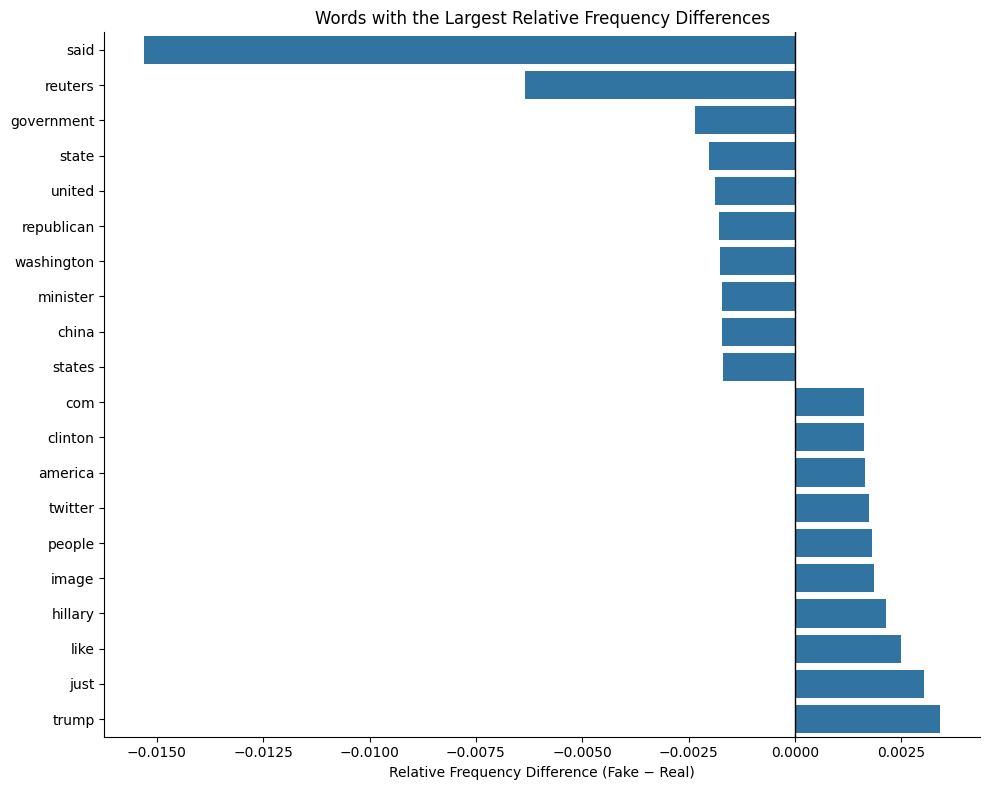

In [91]:
top_fake = word_comparison.nlargest(10, "difference")
top_real = word_comparison.nsmallest(10, "difference")

top_words = pd.concat([top_real, top_fake]).sort_values("difference")

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_words,
    x="difference",
    y="word"
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Words with the Largest Relative Frequency Differences")
plt.xlabel("Relative Frequency Difference (Fake − Real)")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

#### Bigram Analysis

Bigram frequencies were analyzed to capture contextual patterns that cannot be identified from isolated words alone. Relative frequencies were calculated separately for each class, and only bigrams occurring at least 200 times across the corpus were considered.

The analysis reveals substantial differences between fake and real articles.

Several bigrams associated with fake news, such as `featured image`, `twitter com`, `pic twitter`, and `getty images`, appear to reflect website formatting, embedded media, or content-extraction patterns rather than misinformation itself.

Similarly, `washington reuters` and `told reuters` are strongly associated with real articles and provide clear evidence of source-specific information.

Other differences appear thematic or stylistic. Fake articles more frequently reference political figures and social-media-related content, while real articles contain more international and institutional expressions such as `united states`, `north korea`, `prime minister`, and `united nations`. Attribution patterns such as `official said`, `trump said`, and `told reporters` are also more prevalent in real articles.

Overall, the bigram analysis reinforces the presence of significant source and editorial-style artifacts in the dataset. These patterns could allow a classifier to distinguish the original data sources rather than misinformation itself, which must be considered during preprocessing and model evaluation.

In [94]:
def get_bigrams(words):
    return [
        (w1, w2)
        for w1, w2 in zip(words, words[1:])
        if (
            w1 not in ENGLISH_STOP_WORDS
            and w2 not in ENGLISH_STOP_WORDS
            and len(w1) > 1
            and len(w2) > 1
        )
    ]

fake_bigrams = get_bigrams(fake_words)
true_bigrams = get_bigrams(true_words)

In [95]:
fake_bigram_counter = Counter(fake_bigrams)
true_bigram_counter = Counter(true_bigrams)

fake_bigram_counter.most_common(20)

[(('donald', 'trump'), 14118),
 (('featured', 'image'), 7692),
 (('hillary', 'clinton'), 7241),
 (('white', 'house'), 6742),
 (('united', 'states'), 6661),
 (('twitter', 'com'), 6567),
 (('pic', 'twitter'), 6148),
 (('new', 'york'), 4352),
 (('president', 'obama'), 4060),
 (('getty', 'images'), 4022),
 (('president', 'trump'), 3881),
 (('fox', 'news'), 3479),
 (('year', 'old'), 2748),
 (('barack', 'obama'), 2348),
 (('century', 'wire'), 1930),
 (('supreme', 'court'), 1827),
 (('fake', 'news'), 1813),
 (('social', 'media'), 1753),
 (('national', 'security'), 1732),
 (('trump', 'realdonaldtrump'), 1698)]

In [96]:
true_bigram_counter.most_common(20)

[(('united', 'states'), 12021),
 (('donald', 'trump'), 10063),
 (('white', 'house'), 8334),
 (('washington', 'reuters'), 6648),
 (('president', 'donald'), 5872),
 (('north', 'korea'), 5509),
 (('new', 'york'), 4715),
 (('prime', 'minister'), 4108),
 (('told', 'reuters'), 3445),
 (('islamic', 'state'), 3440),
 (('barack', 'obama'), 3329),
 (('told', 'reporters'), 3126),
 (('president', 'barack'), 2945),
 (('trump', 'said'), 2903),
 (('hillary', 'clinton'), 2483),
 (('supreme', 'court'), 2423),
 (('united', 'nations'), 2282),
 (('year', 'old'), 2183),
 (('national', 'security'), 2118),
 (('human', 'rights'), 2064)]

In [97]:
total_fake_bigrams = sum(fake_bigram_counter.values())
total_true_bigrams = sum(true_bigram_counter.values())

In [98]:
fake_bigram_freq = {
    bigram: count / total_fake_bigrams
    for bigram, count in fake_bigram_counter.items()
}

true_bigram_freq = {
    bigram: count / total_true_bigrams
    for bigram, count in true_bigram_counter.items()
}

In [99]:
common_bigrams = {
    bigram
    for bigram in set(fake_bigram_counter) | set(true_bigram_counter)
    if fake_bigram_counter[bigram] + true_bigram_counter[bigram] >= 200
}

In [100]:
bigram_comparison = pd.DataFrame({
    "bigram": [" ".join(bigram) for bigram in common_bigrams],
    "fake_frequency": [
        fake_bigram_freq.get(bigram, 0)
        for bigram in common_bigrams
    ],
    "true_frequency": [
        true_bigram_freq.get(bigram, 0)
        for bigram in common_bigrams
    ]
})

In [101]:
bigram_comparison["difference"] = (
    bigram_comparison["fake_frequency"]
    - bigram_comparison["true_frequency"]
)

In [102]:
bigram_comparison.nlargest(15, "difference")

,bigram,fake_frequency,true_frequency,difference
354,featured image,0.003407,0.000000,0.003407
1113,twitter com,0.002908,0.000000,0.002908
159,pic twitter,0.002723,0.000000,0.002723
722,hillary clinton,0.003207,0.001192,0.002015
926,getty images,0.001781,0.000000,0.001781
343,president obama,0.001798,0.000083,0.001716
186,president trump,0.001719,0.000288,0.001431
702,donald trump,0.006253,0.004831,0.001422
207,fox news,0.001541,0.000312,0.001229
531,century wire,0.000855,0.000000,0.000855


In [103]:
bigram_comparison.nsmallest(15, "difference")

,bigram,fake_frequency,true_frequency,difference
163,washington reuters,0.000001,0.003191,-0.003190
90,united states,0.002950,0.005771,-0.002821
14,president donald,0.000456,0.002819,-0.002363
644,north korea,0.000414,0.002645,-0.002231
638,prime minister,0.000261,0.001972,-0.001711
990,told reuters,0.000026,0.001654,-0.001628
723,islamic state,0.000222,0.001651,-0.001430
110,told reporters,0.000140,0.001501,-0.001361
334,white house,0.002986,0.004001,-0.001015
669,president barack,0.000418,0.001414,-0.000996


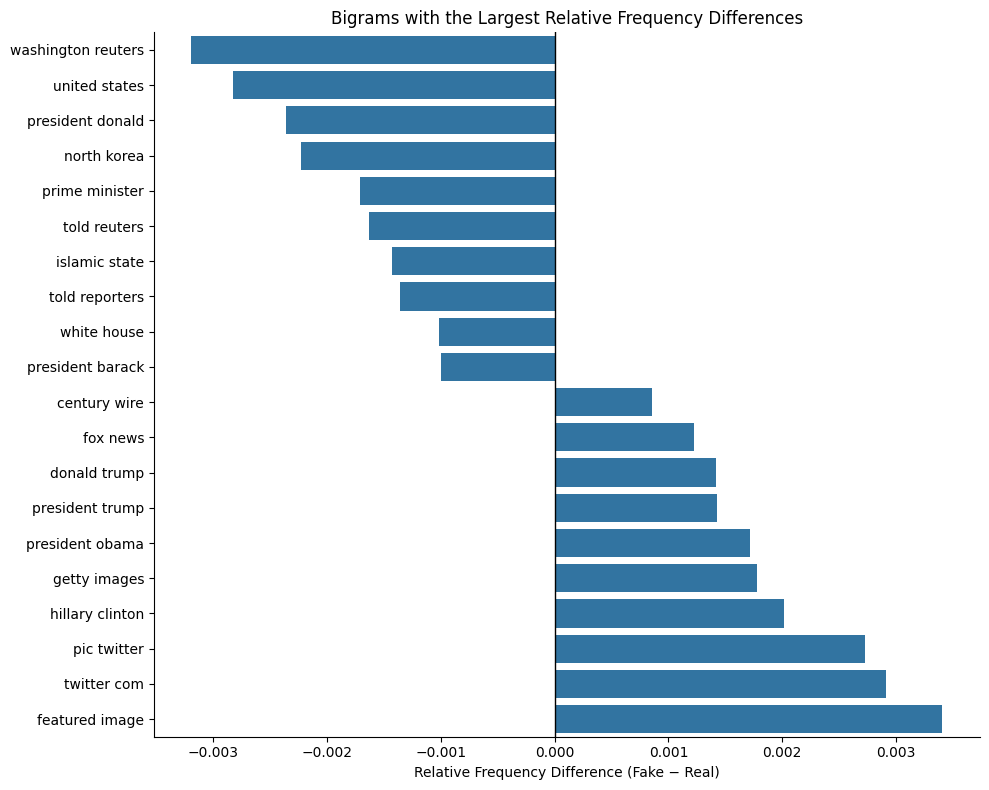

In [104]:
top_fake_bigrams = bigram_comparison.nlargest(10, "difference")
top_real_bigrams = bigram_comparison.nsmallest(10, "difference")

top_bigrams = pd.concat([
    top_real_bigrams,
    top_fake_bigrams
]).sort_values("difference")

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_bigrams,
    x="difference",
    y="bigram"
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Bigrams with the Largest Relative Frequency Differences")
plt.xlabel("Relative Frequency Difference (Fake − Real)")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

#### Stylistic Features

Several stylistic characteristics were examined, including the frequency of exclamation marks, question marks, fully uppercase tokens, and URLs. Counts were normalized per 1,000 words to account for differences in article length.

Mean values initially suggested substantial differences between the two classes, particularly for punctuation and URLs. Fake articles averaged approximately **3.88 exclamation marks, 6.21 question marks, and 7.53 URLs per 1,000 words**, compared with **0.21, 0.19, and 0.005**, respectively, for real articles.

However, the median frequency of exclamation marks, question marks, and URLs is **zero in both classes**. This indicates that these large differences in mean values are not representative of the typical article, but are instead driven by subsets of observations with unusually high frequencies.

This is consistent with the earlier lexical and bigram analyses, which identified source-related patterns such as `twitter com`, `pic twitter`, `featured image`, and `getty images` among fake articles.

Uppercase-token usage shows a less straightforward pattern. Although the mean is higher for fake articles, the median is slightly higher for real articles. Moreover, fully uppercase tokens may include acronyms such as `US`, `FBI`, or `NATO`, so this measure should not be interpreted directly as sensationalist writing.

Overall, stylistic differences exist within the dataset, but several are highly skewed and appear to be associated with particular sources or subsets of articles rather than representing universal differences between fake and real news.

In [105]:
df["exclamation_count"] = df["text"].str.count("!")
df["question_count"] = df["text"].str.count(r"\?")
df["uppercase_count"] = df["text"].apply(
    lambda text: sum(1 for word in text.split() if word.isupper())
)
df["url_count"] = df["text"].str.count(r"https?://|www\.")

In [106]:
style_features = [
    "exclamation_count",
    "question_count",
    "uppercase_count",
    "url_count"
]

for feature in style_features:
    df[f"{feature}_per_1000"] = (
        df[feature] / df["word_count"] * 1000
    )

In [107]:
style_summary = df.groupby("label")[
    [
        "exclamation_count_per_1000",
        "question_count_per_1000",
        "uppercase_count_per_1000",
        "url_count_per_1000"
    ]
].mean()

style_summary

,exclamation_count_per_1000,question_count_per_1000,uppercase_count_per_1000,url_count_per_1000
label,,,,
0,3.878405,6.210470,26.285837,7.529917
1,0.211980,0.187058,20.812472,0.005059


In [108]:
style_median = df.groupby("label")[
    [
        "exclamation_count_per_1000",
        "question_count_per_1000",
        "uppercase_count_per_1000",
        "url_count_per_1000"
    ]
].median()

style_median

,exclamation_count_per_1000,question_count_per_1000,uppercase_count_per_1000,url_count_per_1000
label,,,,
0,0.0,0.0,15.290520,0.0
1,0.0,0.0,17.241379,0.0


## EDA Conclusion & Key Findings

The exploratory data analysis highlighted several important characteristics of the ISOT Fake News Dataset that should be considered before model training.

### 1. Class distribution

The dataset is relatively well balanced between fake and real news articles, limiting the need for specific class-balancing techniques.

### 2. Missing and empty content

No conventional missing values were found. However, 631 articles contained an empty `text` field, almost exclusively belonging to the fake-news class. Since this project focuses on article-content classification, these observations were removed.

### 3. Article length

Fake and real articles show broadly comparable article-length distributions, although fake articles exhibit more extreme long-text outliers. Article length alone therefore does not appear sufficient to distinguish the two classes.

### 4. Lexical differences

Relative word-frequency analysis revealed differences in vocabulary between the two classes. Words such as `trump`, `hillary`, `twitter`, and `image` are relatively more frequent in fake articles, while terms such as `said`, `government`, `state`, and `reuters` are more frequent in real articles.

These differences reflect not only writing style but also differences in topics and article sources.

### 5. Source-related artifacts

A major limitation of the dataset is the presence of strong source-specific signals.

Real articles originate primarily from Reuters, resulting in expressions such as `reuters`, `washington reuters`, and `told reuters` being strongly associated with the real-news class.

Similarly, fake articles contain patterns such as `featured image`, `twitter com`, `pic twitter`, and `getty images`, which likely originate from website formatting, embedded media, or scraping processes.

A classifier trained directly on the raw text could therefore partially learn to identify the source of an article rather than its veracity.

### 6. Stylistic characteristics

Fake articles exhibit substantially higher mean frequencies of exclamation marks, question marks, and URLs. However, the median frequency of these features is zero in both classes, indicating highly skewed distributions driven by subsets of articles rather than systematic differences across all observations.

Uppercase-token usage also showed no simple class-level pattern.

### 7. Implications for modelling

The EDA reveals that high classification performance on this dataset must be interpreted cautiously. Source, topic, formatting, and editorial-style differences may provide shortcuts that allow a model to distinguish the two classes without genuinely identifying misinformation.

The preprocessing and modelling stages will therefore aim to reduce obvious source-specific artifacts and establish a reproducible baseline before evaluating more advanced approaches.